Le pricing des billets d’avion est un enjeu important pour les compagnies aériennes, 
car les prix varient selon de nombreux facteurs (date, demande, destination,etc). 
Le problème consiste à comprendre ces variations et à prédire le prix des billets. 
Ce projet cherche donc à identifier les facteurs influents et à construire un modèle capable d’estimer les prix.

1-Préparation et prétraitement des données 

In [112]:
import pandas as pd
import numpy as np
import re

In [113]:
data_Train = pd.read_excel("Data_Train.xlsx")
data_Test = pd.read_excel("Test_set.xlsx")
data_prediction_test = pd.read_excel("Sample_submission.xlsx")


In [114]:
data_Train.head(15)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
5,SpiceJet,24/06/2019,Kolkata,Banglore,CCU → BLR,09:00,11:25,2h 25m,non-stop,No info,3873
6,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,18:55,10:25 13 Mar,15h 30m,1 stop,In-flight meal not included,11087
7,Jet Airways,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:00,05:05 02 Mar,21h 5m,1 stop,No info,22270
8,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:55,10:25 13 Mar,25h 30m,1 stop,In-flight meal not included,11087
9,Multiple carriers,27/05/2019,Delhi,Cochin,DEL → BOM → COK,11:25,19:15,7h 50m,1 stop,No info,8625


In [115]:
# infos du dataset d'entrainement 
data_Train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [116]:
# descriprion ses données d'entrainnement
data_Train.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [117]:
#rechercheons les valeures nulles,
data_Train.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [118]:
data_Train[data_Train.isnull().any(axis=1)]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [119]:
#drop the nullvalues
data_Train.dropna(inplace=True)

In [120]:
data_Train.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

In [121]:
def change_into_datetime(col):
    data_Train[col]=pd.to_datetime(data_Train[col])

In [122]:
for i in ['Date_of_Journey','Dep_Time', 'Arrival_Time']:
    change_into_datetime(i)

C:\Users\landr\AppData\Local\Temp\ipykernel_34592\799145402.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data_Train[col]=pd.to_datetime(data_Train[col])
C:\Users\landr\AppData\Local\Temp\ipykernel_34592\799145402.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_Train[col]=pd.to_datetime(data_Train[col])
C:\Users\landr\AppData\Local\Temp\ipykernel_34592\799145402.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_Train[col]=pd.to_datetime(data_Train[col])


In [123]:
data_Train.dtypes

Airline                    object
Date_of_Journey    datetime64[ns]
Source                     object
Destination                object
Route                      object
Dep_Time           datetime64[ns]
Arrival_Time       datetime64[ns]
Duration                   object
Total_Stops                object
Additional_Info            object
Price                       int64
dtype: object

In [124]:
data_Train.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-03-23 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-03-23 05:50:00,2026-03-23 13:15:00,7h 25m,2 stops,No info,7662
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-03-23 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,2026-03-23 18:05:00,2026-03-23 23:30:00,5h 25m,1 stop,No info,6218
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,2026-03-23 16:50:00,2026-03-23 21:35:00,4h 45m,1 stop,No info,13302


In [125]:
data_Train["mois_depart"] = data_Train["Date_of_Journey"].dt.month
data_Train["jour_depart"] = data_Train["Date_of_Journey"].dt.day

In [126]:
data_Train.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,mois_depart,jour_depart
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-03-23 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,3,24
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-03-23 05:50:00,2026-03-23 13:15:00,7h 25m,2 stops,No info,7662,5,1
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-03-23 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882,6,9
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,2026-03-23 18:05:00,2026-03-23 23:30:00,5h 25m,1 stop,No info,6218,5,12
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,2026-03-23 16:50:00,2026-03-23 21:35:00,4h 45m,1 stop,No info,13302,3,1


In [127]:
data_Train["Dep_Time"] = data_Train["Dep_Time"].dt.strftime("%H:%M")
data_Train["Arrival_Time"] = data_Train["Arrival_Time"].dt.strftime("%H:%M")

In [128]:
data_Train.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,mois_depart,jour_depart
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10,2h 50m,non-stop,No info,3897,3,24
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,5,1
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25,19h,2 stops,No info,13882,6,9
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,5,12
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,3,1


In [129]:
def convertion_duree(x):
    x = str(x)
    h = 0
    m = 0

    if "h" in x:
        h = int(x.split("h")[0])

    if "m" in x:
        if "h" in x:
            m = int(x.split("h")[1].replace("m", "").strip())
        else:
            m = int(x.replace("m", ""))

    return h*60 + m

data_Train["duree_min"] = data_Train["Duration"].apply(convertion_duree)

In [130]:
data_Train.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,mois_depart,jour_depart,duree_min
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10,2h 50m,non-stop,No info,3897,3,24,170
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,5,1,445
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25,19h,2 stops,No info,13882,6,9,1140
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,5,12,325
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,3,1,285


In [131]:
data_Train["Airline"].value_counts()

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1751
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

In [132]:
data_Train["Route"].value_counts()

Route
DEL → BOM → COK                      2376
BLR → DEL                            1552
CCU → BOM → BLR                       979
CCU → BLR                             724
BOM → HYD                             621
                                     ... 
BOM → VNS → DEL → HYD                   1
BLR → HBX → BOM → NAG → DEL             1
BLR → BOM → IXC → DEL                   1
BLR → CCU → BBI → HYD → VGA → DEL       1
BOM → BBI → HYD                         1
Name: count, Length: 128, dtype: int64

In [133]:
data_Train.drop("Route", axis=1, inplace=True)

In [134]:
data_Train.head()

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,mois_depart,jour_depart,duree_min
0,IndiGo,2019-03-24,Banglore,New Delhi,22:20,01:10,2h 50m,non-stop,No info,3897,3,24,170
1,Air India,2019-05-01,Kolkata,Banglore,05:50,13:15,7h 25m,2 stops,No info,7662,5,1,445
2,Jet Airways,2019-06-09,Delhi,Cochin,09:25,04:25,19h,2 stops,No info,13882,6,9,1140
3,IndiGo,2019-05-12,Kolkata,Banglore,18:05,23:30,5h 25m,1 stop,No info,6218,5,12,325
4,IndiGo,2019-03-01,Banglore,New Delhi,16:50,21:35,4h 45m,1 stop,No info,13302,3,1,285


In [135]:
data_Train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10682 non-null  object        
 1   Date_of_Journey  10682 non-null  datetime64[ns]
 2   Source           10682 non-null  object        
 3   Destination      10682 non-null  object        
 4   Dep_Time         10682 non-null  object        
 5   Arrival_Time     10682 non-null  object        
 6   Duration         10682 non-null  object        
 7   Total_Stops      10682 non-null  object        
 8   Additional_Info  10682 non-null  object        
 9   Price            10682 non-null  int64         
 10  mois_depart      10682 non-null  int32         
 11  jour_depart      10682 non-null  int32         
 12  duree_min        10682 non-null  int64         
dtypes: datetime64[ns](1), int32(2), int64(2), object(8)
memory usage: 1.1+ MB


In [136]:
data_Train["dep_hour"] = data_Train["Dep_Time"].str.split(":").str[0].astype(int)
data_Train["arr_hour"] = data_Train["Arrival_Time"].str.split(":").str[0].astype(int)

In [137]:
def periode_jour(h):
    if h < 6:
        return "nuit"
    elif h < 12:
        return "matin"
    elif h < 18:
        return "apres_midi"
    else:
        return "soir"

data_Train["periode_depart"] = data_Train["dep_hour"].apply(periode_jour)

In [138]:
data_Train.head()

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,mois_depart,jour_depart,duree_min,dep_hour,arr_hour,periode_depart
0,IndiGo,2019-03-24,Banglore,New Delhi,22:20,01:10,2h 50m,non-stop,No info,3897,3,24,170,22,1,soir
1,Air India,2019-05-01,Kolkata,Banglore,05:50,13:15,7h 25m,2 stops,No info,7662,5,1,445,5,13,nuit
2,Jet Airways,2019-06-09,Delhi,Cochin,09:25,04:25,19h,2 stops,No info,13882,6,9,1140,9,4,matin
3,IndiGo,2019-05-12,Kolkata,Banglore,18:05,23:30,5h 25m,1 stop,No info,6218,5,12,325,18,23,soir
4,IndiGo,2019-03-01,Banglore,New Delhi,16:50,21:35,4h 45m,1 stop,No info,13302,3,1,285,16,21,apres_midi


In [139]:
data_Train["Additional_Info"].value_counts()

Additional_Info
No info                         8344
In-flight meal not included     1982
No check-in baggage included     320
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [140]:
data_Train["Additional_Info"] = (
    data_Train["Additional_Info"]
    .str.lower()
    .str.strip()
)

In [141]:
data_Train["Additional_Info"].value_counts()

Additional_Info
no info                         8347
in-flight meal not included     1982
no check-in baggage included     320
1 long layover                    19
change airports                    7
business class                     4
1 short layover                    1
red-eye flight                     1
2 long layover                     1
Name: count, dtype: int64

In [142]:
data_Train["Source"] = (
    data_Train["Source"]
    .str.lower()
    .str.strip()
)

In [143]:
data_Train["Destination"] = (
    data_Train["Destination"]
    .str.lower()
    .str.strip()
)

In [144]:
data_Train.head()

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,mois_depart,jour_depart,duree_min,dep_hour,arr_hour,periode_depart
0,IndiGo,2019-03-24,banglore,new delhi,22:20,01:10,2h 50m,non-stop,no info,3897,3,24,170,22,1,soir
1,Air India,2019-05-01,kolkata,banglore,05:50,13:15,7h 25m,2 stops,no info,7662,5,1,445,5,13,nuit
2,Jet Airways,2019-06-09,delhi,cochin,09:25,04:25,19h,2 stops,no info,13882,6,9,1140,9,4,matin
3,IndiGo,2019-05-12,kolkata,banglore,18:05,23:30,5h 25m,1 stop,no info,6218,5,12,325,18,23,soir
4,IndiGo,2019-03-01,banglore,new delhi,16:50,21:35,4h 45m,1 stop,no info,13302,3,1,285,16,21,apres_midi


In [145]:
data_Train["Total_Stops"].value_counts()

Total_Stops
1 stop      5625
non-stop    3491
2 stops     1520
3 stops       45
4 stops        1
Name: count, dtype: int64

In [146]:
data_Train["Total_Stops"] = data_Train["Total_Stops"].replace({
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
})

C:\Users\landr\AppData\Local\Temp\ipykernel_34592\2653556922.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_Train["Total_Stops"] = data_Train["Total_Stops"].replace({


In [147]:
data_Train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10682 non-null  object        
 1   Date_of_Journey  10682 non-null  datetime64[ns]
 2   Source           10682 non-null  object        
 3   Destination      10682 non-null  object        
 4   Dep_Time         10682 non-null  object        
 5   Arrival_Time     10682 non-null  object        
 6   Duration         10682 non-null  object        
 7   Total_Stops      10682 non-null  int64         
 8   Additional_Info  10682 non-null  object        
 9   Price            10682 non-null  int64         
 10  mois_depart      10682 non-null  int32         
 11  jour_depart      10682 non-null  int32         
 12  duree_min        10682 non-null  int64         
 13  dep_hour         10682 non-null  int64         
 14  arr_hour         10682 non-null  int64     

In [148]:
data_Train.head()

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,mois_depart,jour_depart,duree_min,dep_hour,arr_hour,periode_depart
0,IndiGo,2019-03-24,banglore,new delhi,22:20,01:10,2h 50m,0,no info,3897,3,24,170,22,1,soir
1,Air India,2019-05-01,kolkata,banglore,05:50,13:15,7h 25m,2,no info,7662,5,1,445,5,13,nuit
2,Jet Airways,2019-06-09,delhi,cochin,09:25,04:25,19h,2,no info,13882,6,9,1140,9,4,matin
3,IndiGo,2019-05-12,kolkata,banglore,18:05,23:30,5h 25m,1,no info,6218,5,12,325,18,23,soir
4,IndiGo,2019-03-01,banglore,new delhi,16:50,21:35,4h 45m,1,no info,13302,3,1,285,16,21,apres_midi


In [149]:
data_Train["Total_Stops"] = data_Train["Total_Stops"].astype(int)

2- Visualisation des données:
cette approche est utilisé pour:
-comprendre les rélations entre les données et déterminer les données importantes 
-mener des analyse données
-comprendre la répartition des données 

In [150]:
#importation des bibiothèques utiles
import seaborn as sns 
import matplotlib.pyplot as plt

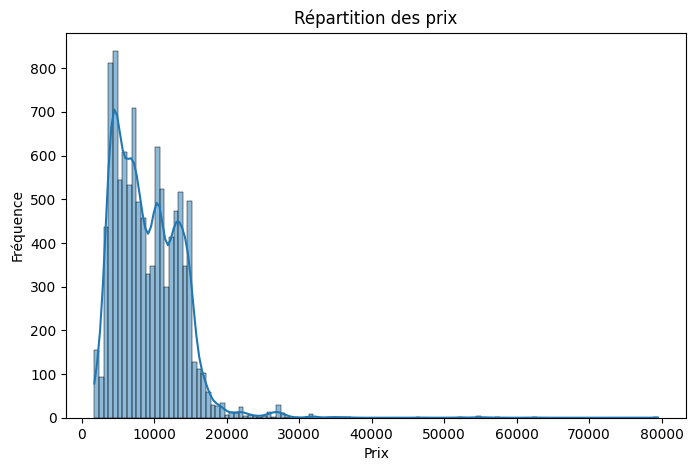

In [162]:
#Visualisation de la répartition des données: ce visuel permet de voir la répartition des données( symetrique/asymétrique) 
#---ce visuel permet également de déterminé les valeurs abérante qui pourrais influencer les corrélations

plt.figure(figsize=(8,5))
sns.histplot(data_Train['Price'], kde=True)  # kde = courbe de densité
plt.title('Répartition des prix')
plt.xlabel('Prix')
plt.ylabel('Fréquence')
plt.show()

Interprétation: ce visuel permet de voir que les données sont asymétrique, ceci nous permet de comprends qu'il serait important d'utiliser les valeurs médianes aux valeurs moyenne dans nos calculs car les valeurs médiane ne sont pas affectés par la répartition asymétrique comme les valeurs moyenne
deplus on constate qu'il y'a pas de valeurs abérantes

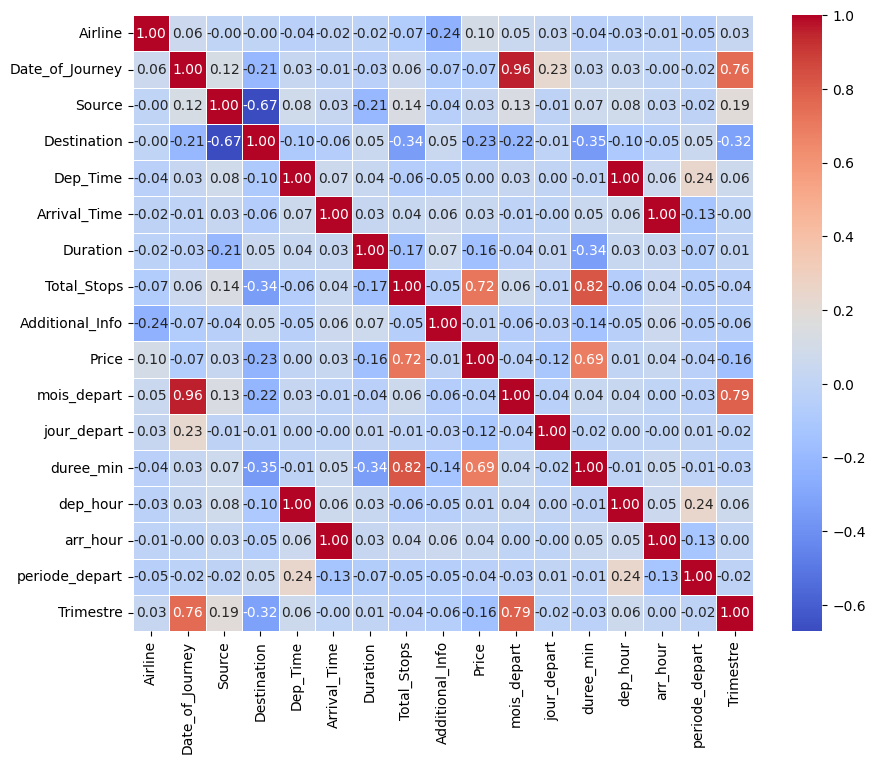

In [151]:
#Matrice de correlation: nécéssaire pour trouver les rélations entre les variables

#--création de la colone Trimestre pour vérifier si le prix du billet d'avion dépend de la période
data_Train['Trimestre'] = ((data_Train['mois_depart'] - 1) // 3) + 1

#encodage des variables catégorielle pour etre sur d'avoir toute les corrélation dans le dataset
from sklearn.preprocessing import LabelEncoder
plt.figure(figsize=(10, 8))
df_encoded = data_Train.copy()

le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

#matrice de correlation en représentation graphique pour avoir une meilleur vue sur les coefficients et les corrélation dans le dataset
corr = df_encoded.corr(method='spearman')

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.show()

interprétation: de cette matrice de correlation on voit qu'il n'ya que la durée du vol et le nombre de stop qui sont en corrélation linéaire forte avec le prix des billets,tant dis que les autres sont en faible corrélation linéair,
N.B: ceci ne veut pas dire qu'il y'a pas de rélation entre le prix et les autres valeurs, juste que cette rélation n'est pas linéaire

Nous allons maintenant nous pencher sur une analyse visuelle des différents parametres pouvant influencer le prix des billets d'avion 

In [ ]:
#vérifier le nombre de vols par trimestre
data=data_Train.groupby("Trimestre")["Trimestre"].count()
data

Trimestre
1    2724
2    7958
Name: Trimestre, dtype: int64

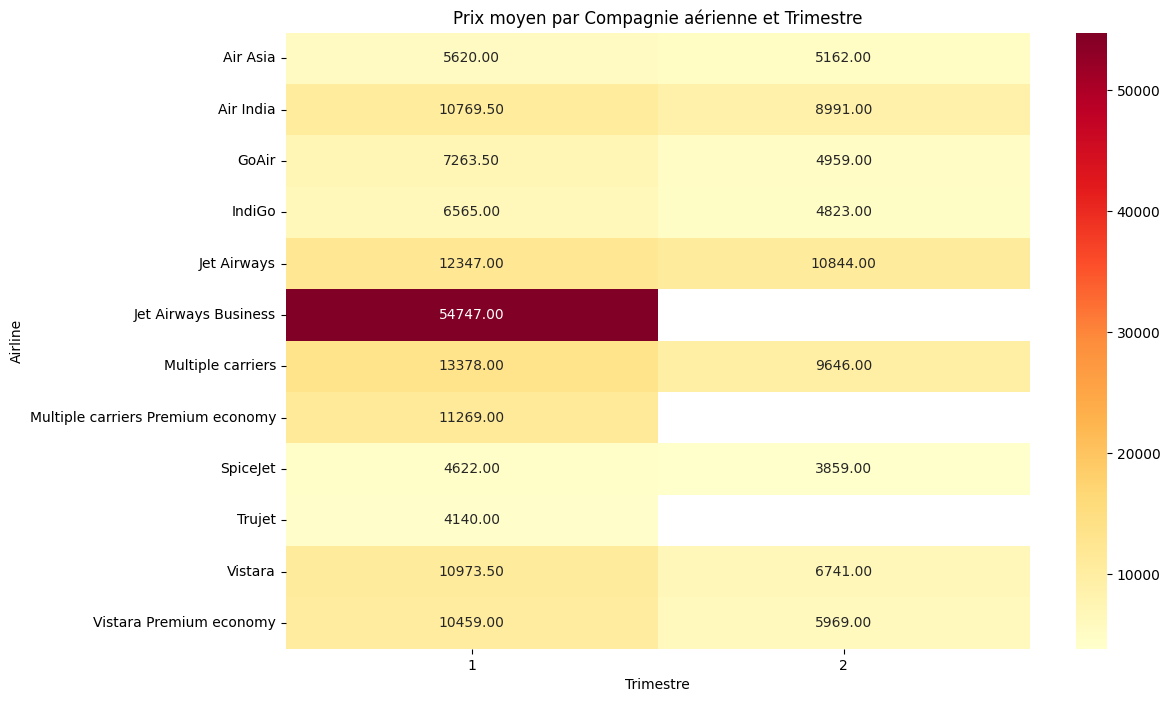

In [ ]:
#visuel des prix en fonctions des campagnies et des trimestres
data1=data_Train.groupby("Trimestre")["Price"].mean()
import seaborn as sns
import matplotlib.pyplot as plt

pivot_table = data_Train.pivot_table(values='Price', index='Airline', columns='Trimestre', aggfunc='median')

plt.figure(figsize=(12,8))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title('Prix median par Compagnie aérienne et Trimestre')
plt.ylabel('Airline')
plt.xlabel('Trimestre')
plt.show()

on voit ici que les prix sont influencés par la compagnie aériennes et par la période de l'année de l'année

C:\Users\landr\AppData\Local\Temp\ipykernel_34592\2195404964.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(y=data2["mois_depart"], x=data2["count"],orient='h',palette='viridis')


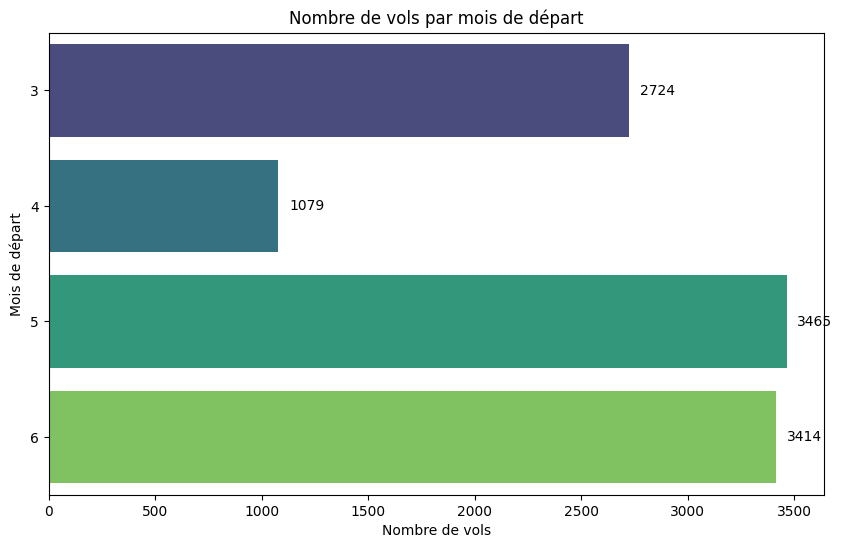

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns
data2 = data_Train.groupby("mois_depart")["mois_depart"].count().reset_index(name='count')
plt.figure(figsize=(10,6))
barplot = sns.barplot(y=data2["mois_depart"], x=data2["count"],orient='h',palette='viridis')

plt.xlabel('Nombre de vols')
plt.ylabel('Mois de départ')
plt.title('Nombre de vols par mois de départ')

# Ajouter les valeurs au bout des barres
for index, value in enumerate(data2["count"]):
    barplot.text(value + 50, index, str(value), va='center')

plt.show()

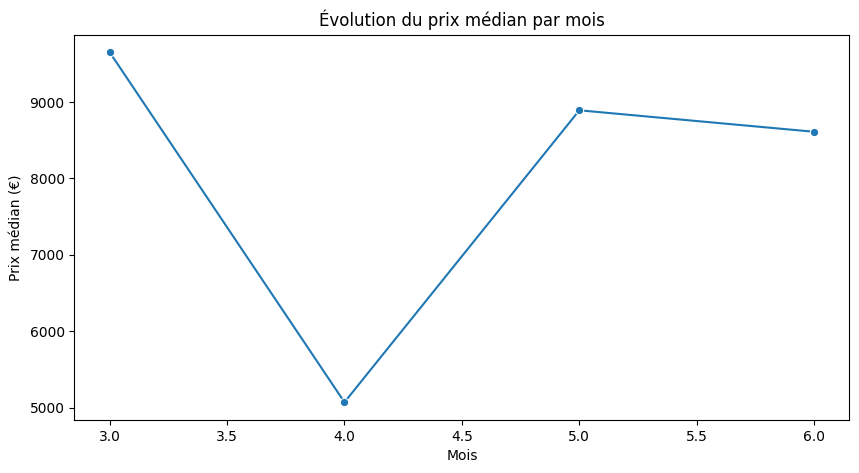

In [171]:
median_price_month = data_Train.groupby('mois_depart')['Price'].median().reset_index()
plt.figure(figsize=(10,5))

sns.lineplot(data=median_price_month, x='mois_depart', y='Price', marker='o')

plt.title('Évolution du prix médian par mois')
plt.xlabel('Mois')
plt.ylabel('Prix médian (€)')
plt.show()

C:\Users\landr\AppData\Local\Temp\ipykernel_34592\1466934195.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=mean_price_by_stops, x='Total_Stops', y='Price', palette='coolwarm')


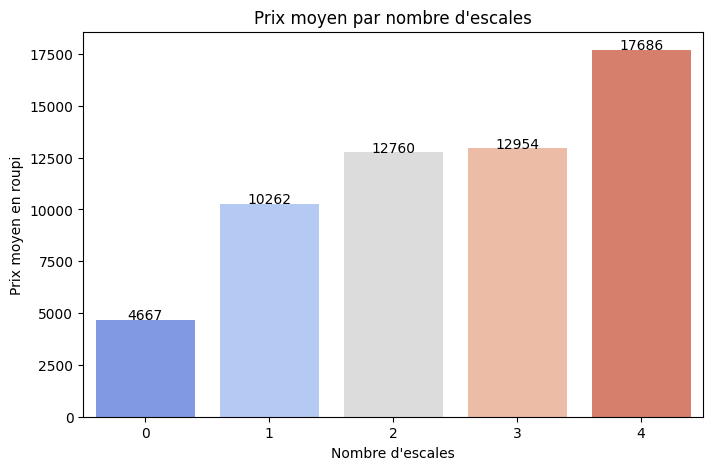

In [ ]:
#visualisation du prix par nombre d'escale
plt.figure(figsize=(8,5))
median_price_by_stops = data_Train.groupby('Total_Stops')['Price'].median().reset_index()
ax = sns.barplot(data=median_price_by_stops, x='Total_Stops', y='Price', palette='coolwarm')

# Ajout des valeurs sur le graphes
for i, value in enumerate(median_price_by_stops['Price']):
    ax.text(i, value + 10, f'{value:.0f}', ha='center')

plt.xlabel('Nombre d\'escales')
plt.ylabel('Prix moyen en roupi')
plt.title('Prix moyen par nombre d\'escales')
plt.show()

comme obtenu dans la matrice de correlation, le prix est bien lié au prix et plus il y'a d'escale, plus le prix est élévé

C:\Users\landr\AppData\Local\Temp\ipykernel_34592\1336604625.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=median_price, x='periode_depart', y='Price', palette='viridis')


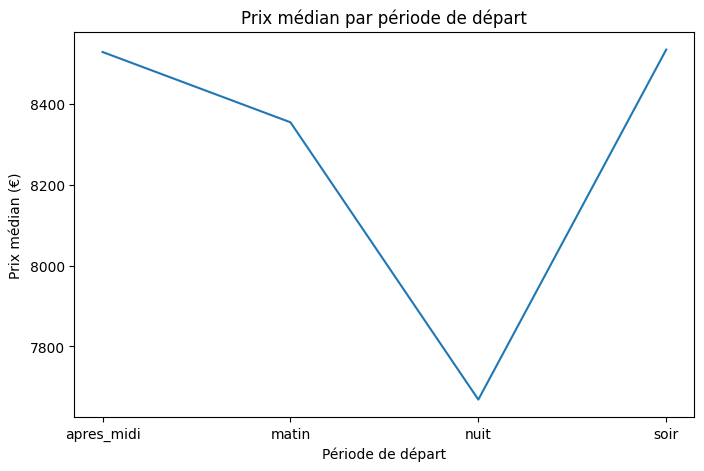

In [ ]:
#prix par période de départ
median_price = data_Train.groupby('periode_depart')['Price'].median().reset_index()
median_price
plt.figure(figsize=(8,5))
sns.lineplot(data=median_price, x='periode_depart', y='Price', palette='viridis')

plt.xlabel('Période de départ')
plt.ylabel('Prix médian (€)')
plt.title('Prix médian par période de départ')
plt.show()

ce graphe nous permet de comprendre également que le prix est influencé par la péridoe de départ